In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

The dataset contains daily bike-sharing information along with weather, seasonal, and calendar-related features.
These variables can be used to understand and predict daily bike rental demand.

In [2]:
df = pd.read_csv('day.csv')

In [3]:
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [6]:
df.shape

(731, 16)

###Missing Value Check
The dataset does not contain missing values in the available features.

Therefore, no missing-value imputation is required before modeling.

In [8]:
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [9]:
df.drop(columns=['instant','casual','registered'],inplace=True)

In [10]:
df.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


The cnt variable represents the total number of bike rentals recorded each day.

It is used as the target variable for the regression models.

In [11]:
df["cnt"].describe()

,cnt
count,731.000000
mean,4504.348837
std,1937.211452
min,22.000000
25%,3152.000000
50%,4548.000000
75%,5956.000000
max,8714.000000


In [19]:
df.corr(numeric_only=True)["cnt"].sort_values(ascending=False)

,cnt
cnt,1.000000
atemp,0.631066
temp,0.627494
yr,0.566710
season,0.406100
mnth,0.279977
weekday,0.067443
workingday,0.061156
holiday,-0.068348
hum,-0.100659


The histogram shows the distribution of daily bike rentals.

Rental counts vary considerably across different days, indicating variation in bike-sharing demand.

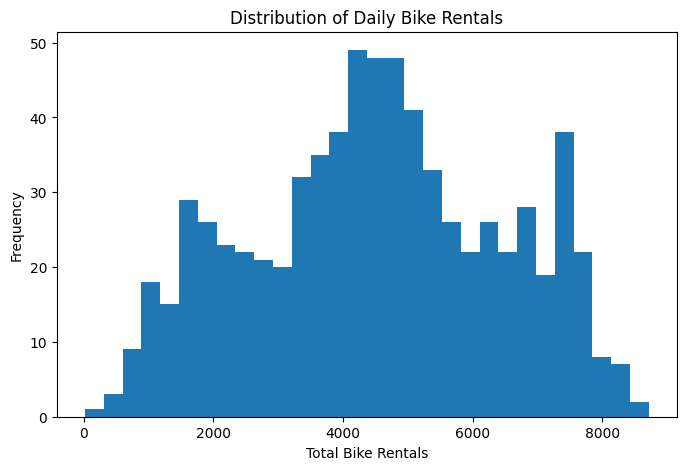

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df["cnt"], bins=30)

plt.xlabel("Total Bike Rentals")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Bike Rentals")

plt.show()

The scatter plot shows a positive relationship between temperature and bike rentals.

Bike rental demand generally increases as temperature becomes more favorable.

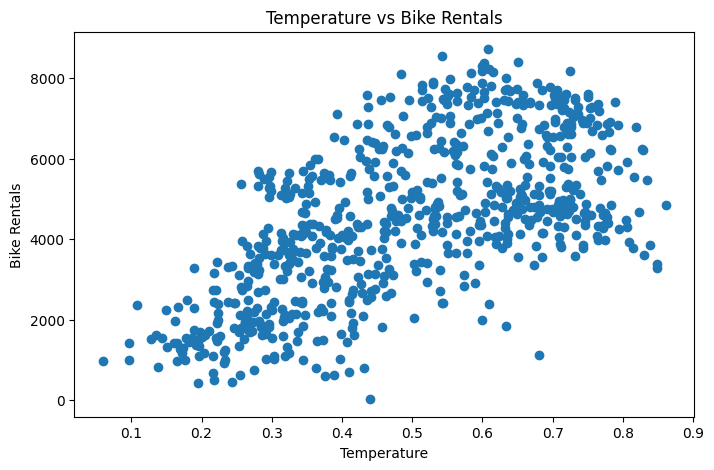

In [14]:
plt.figure(figsize=(8,5))

plt.scatter(df["temp"], df["cnt"])

plt.xlabel("Temperature")
plt.ylabel("Bike Rentals")
plt.title("Temperature vs Bike Rentals")

plt.show()

The heatmap shows the correlation between the numerical variables in the dataset.

It helps identify important relationships as well as highly correlated features that may cause multicollinearity.

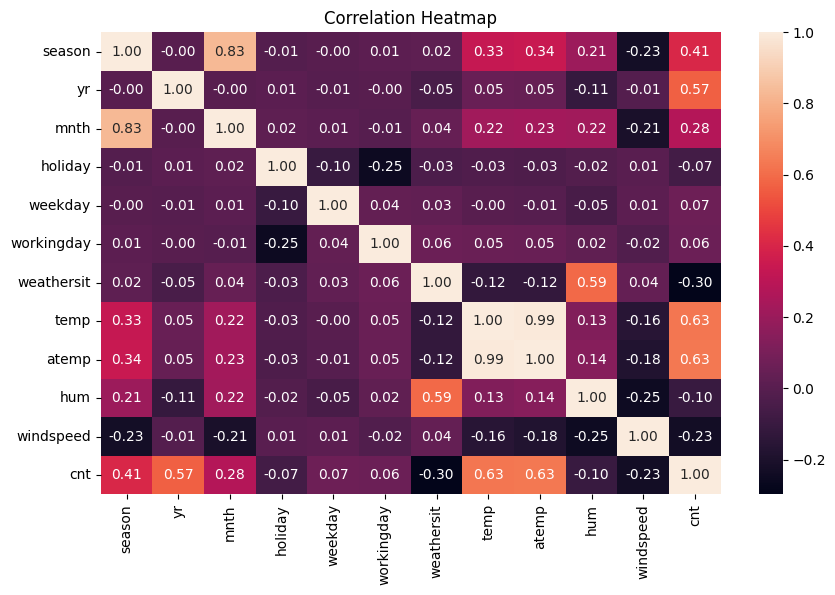

In [24]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [25]:
df.drop(columns=['atemp'],inplace=True)

In [26]:
features = [
    "season",
    "yr",
    "mnth",
    "holiday",
    "weekday",
    "workingday",
    "weathersit",
    "temp",
    "hum",
    "windspeed"
]

X = df[features]
y = df["cnt"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (584, 10)
Testing data: (147, 10)


Multiple Linear Regression models the relationship between bike rentals and multiple input features using a linear relationship.

It provides a strong baseline for comparing more complex regression models.

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
lr=LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [31]:
y_pred = lr.predict(X_test)

The plot compares the actual bike rentals with the values predicted by the Linear Regression model.

Predictions closer to the diagonal line indicate better model performance.

In [32]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(10))

   Actual    Predicted
0    6606  6196.451168
1    1550  1637.457922
2    3747  3071.724674
3    6041  4300.955701
4    7538  6688.154005
5    7264  7305.382483
6    1605   811.368385
7    2209  2079.257586
8    7499  7163.678083
9    5743  6444.622980


In [33]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [34]:
mae = mean_absolute_error(y_test, y_pred)

In [35]:
mse = mean_squared_error(y_test, y_pred)

In [36]:
rmse = np.sqrt(mse)

In [37]:
r2 = r2_score(y_test, y_pred)

In [38]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 620.6250906069755
MSE : 693530.0531600621
RMSE: 832.7845178436388
R²  : 0.8270447850465307


In [39]:
residuals = y_test - y_pred

print(residuals.head())

703     409.548832
33      -87.457922
300     675.275326
456    1740.044299
633     849.845995
Name: cnt, dtype: float64


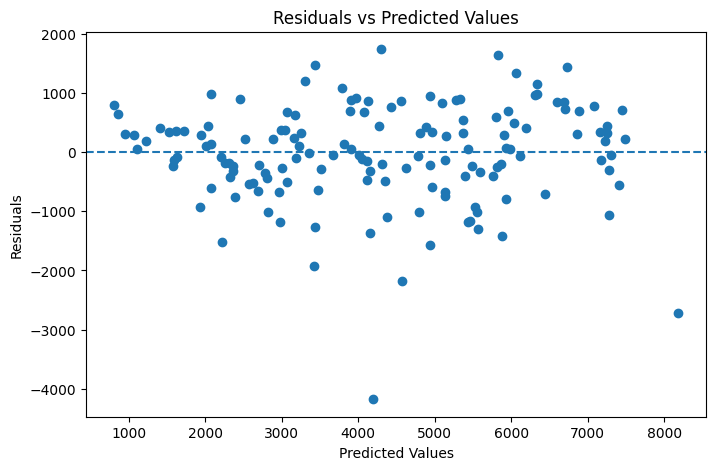

In [40]:
plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()

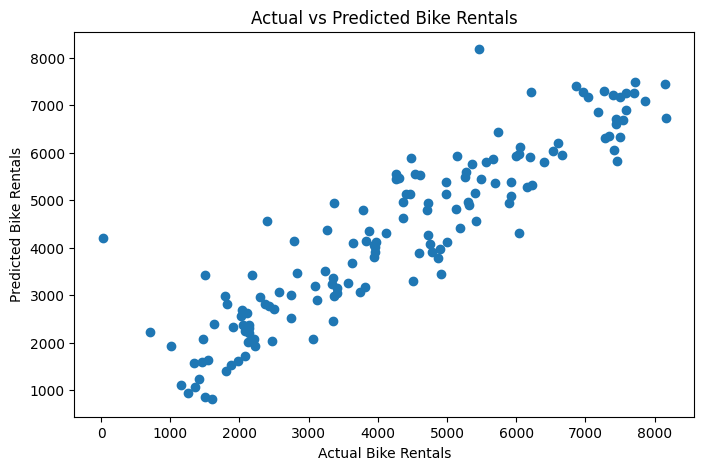

In [41]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Actual vs Predicted Bike Rentals")

plt.show()

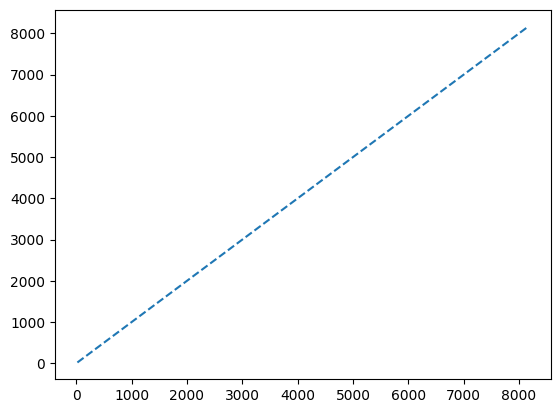

In [42]:
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

Polynomial Regression extends the linear model by adding nonlinear terms and feature interactions.

It helps capture curved relationships that cannot be represented effectively by a simple linear model

In [57]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(
    degree=2,
    include_bias=False
)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

print("Original features:", X_train.shape[1])
print("Polynomial features:", X_train_poly.shape[1])

Original features: 10
Polynomial features: 65


In [58]:
poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

LinearRegression()

In [59]:
y_pred_poly = poly_model.predict(X_test_poly)

In [60]:
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("Polynomial Regression")
print("--------------------")
print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE:", rmse_poly)
print("R²  :", r2_poly)

Polynomial Regression
--------------------
MAE : 533.6071637847707
MSE : 493378.57398173964
RMSE: 702.409121510918
R²  : 0.8769593373385453


Random Forest Regression combines multiple decision trees to capture complex nonlinear relationships between the features and bike rental demand.

It can model interactions between features without assuming a linear relationship.

In [75]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [62]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression")
print("-----------------------")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regression
-----------------------
MAE : 427.80659863945573
MSE : 455022.88086258504
RMSE: 674.5538383721384
R²  : 0.8865246288754957


The models are compared using MAE, RMSE, and R² to identify the best-performing regression approach.

Lower MAE and RMSE and higher R² indicate better predictive performance.

In [63]:
results = pd.DataFrame({
    "Model": [
        "Multiple Linear Regression",
        "Polynomial Regression",
        "Random Forest Regression"
    ],
    "MAE": [
        mae,
        mae_poly,
        mae_rf
    ],
    "RMSE": [
        rmse,
        rmse_poly,
        rmse_rf
    ],
    "R2": [
        r2,
        r2_poly,
        r2_rf
    ]
})

results

,Model,MAE,RMSE,R2
0,Multiple Linear Regression,620.625091,832.784518,0.827045
1,Polynomial Regression,533.607164,702.409122,0.876959
2,Random Forest Regression,427.806599,674.553838,0.886525


Feature importance shows the contribution of each input feature to the Random Forest predictions.

Features with higher importance have a greater influence on the model's prediction of bike rental demand.

In [76]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

      Feature  Importance
7        temp    0.484147
1          yr    0.283109
0      season    0.060678
8         hum    0.060034
9   windspeed    0.035885
2        mnth    0.031137
6  weathersit    0.019944
4     weekday    0.016775
5  workingday    0.005478
3     holiday    0.002813


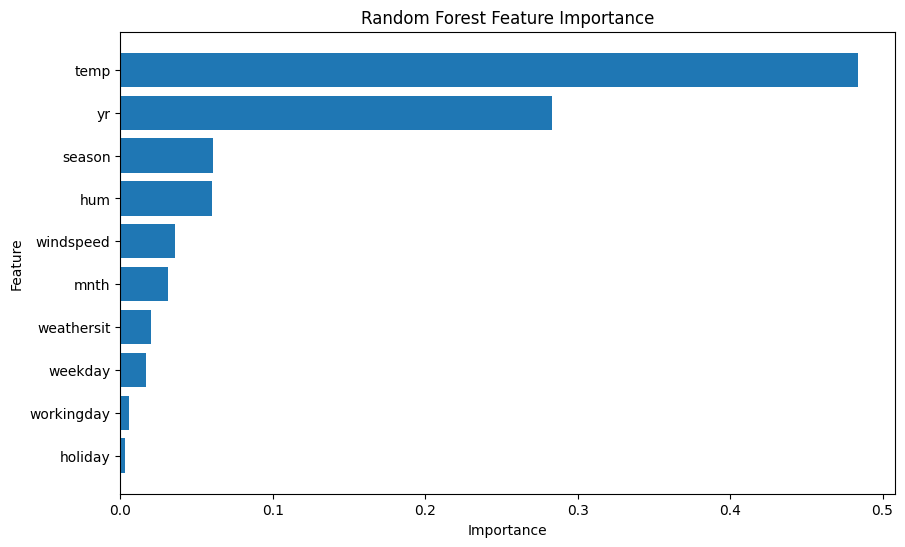

In [77]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

Random Forest Regression provides the best overall performance among the evaluated models.

It is selected as the final model for predicting daily bike rental demand.

In [78]:
import joblib

In [80]:
joblib.dump(
    lr,
    "multiple_linear_regression.pkl"
)

joblib.dump(
    poly_model,
    "polynomial_regression_degree2.pkl"
)

joblib.dump(
    rf,
    "random_forest_regression.pkl"
)

['random_forest_regression.pkl']

In [81]:
df.to_csv(
    "bike_preprocessed.csv",
    index=False
)